In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# Download data
data = yf.download(['JPM', 'BAC'], start='2020-01-01', end='2024-12-31')['Close']
data.dropna(inplace=True)

print(data.head())
print(f"\nShape: {data.shape}")

[*********************100%***********************]  2 of 2 completed

Ticker            BAC         JPM
Date                             
2020-01-02  30.587568  118.430328
2020-01-03  29.952469  116.867462
2020-01-06  29.909550  116.774559
2020-01-07  29.712156  114.789322
2020-01-08  30.012539  115.684761

Shape: (1257, 2)


In [6]:
# Cointegration Test - do stocks saath move karte hain kya?
score, pvalue, _ = coint(data['JPM'], data['BAC'])

print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("✅ Cointegrated! Pairs trading possible.")
else:
    print("❌ Not cointegrated.")

P-value: 0.9872
❌ Not cointegrated.


In [7]:
data = yf.download(['KO', 'PEP'], start='2020-01-01', end='2024-12-31')['Close']
data.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


In [8]:
data = yf.download(['SPY', 'IVV'], start='2020-01-01', end='2024-12-31')['Close']
data.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


In [10]:
# Cointegration Test - do stocks saath move karte hain kya?
score, pvalue, _ = coint(data['SPY'], data['IVV'])

print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("✅ Cointegrated! Pairs trading possible.")
else:
    print("❌ Not cointegrated.")

P-value: 0.2429
❌ Not cointegrated.


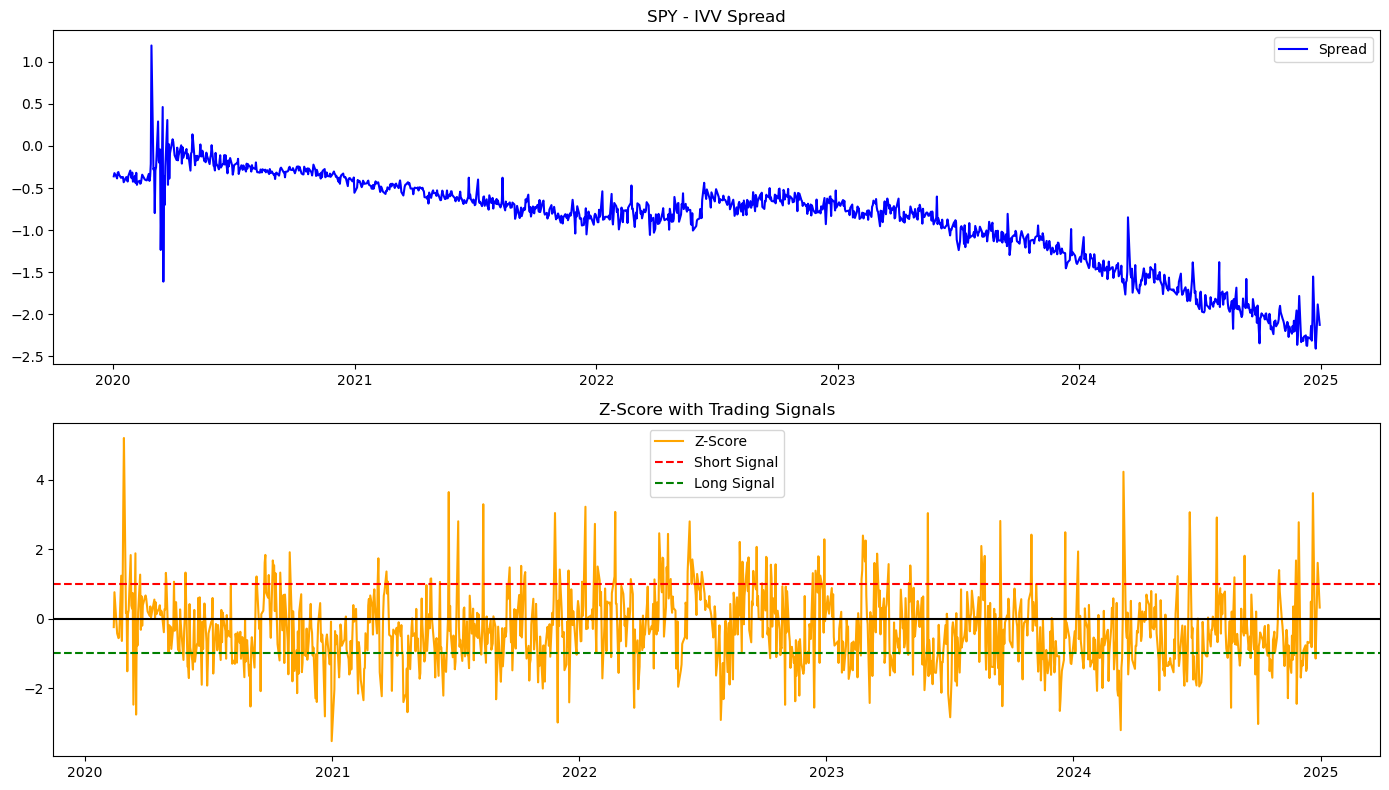

Total Long signals: 314
Total Short signals: 115


In [11]:
# Spread calculate karo
spread = data['SPY'] - data['IVV']

# Z-score banao
spread_mean = spread.rolling(window=30).mean()
spread_std = spread.rolling(window=30).std()
zscore = (spread - spread_mean) / spread_std

# Trading Signals
signals = pd.DataFrame(index=data.index)
signals['zscore'] = zscore
signals['long'] = (zscore < -1).astype(int)   # Buy when spread too low
signals['short'] = (zscore > 1).astype(int)    # Sell when spread too high

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(spread, label='Spread', color='blue')
ax1.set_title('SPY - IVV Spread')
ax1.legend()

ax2.plot(zscore, label='Z-Score', color='orange')
ax2.axhline(1, color='red', linestyle='--', label='Short Signal')
ax2.axhline(-1, color='green', linestyle='--', label='Long Signal')
ax2.axhline(0, color='black', linestyle='-')
ax2.set_title('Z-Score with Trading Signals')
ax2.legend()

plt.tight_layout()
plt.savefig('pairs_trading_signals.png', dpi=150)
plt.show()

print(f"Total Long signals: {signals['long'].sum()}")
print(f"Total Short signals: {signals['short'].sum()}")

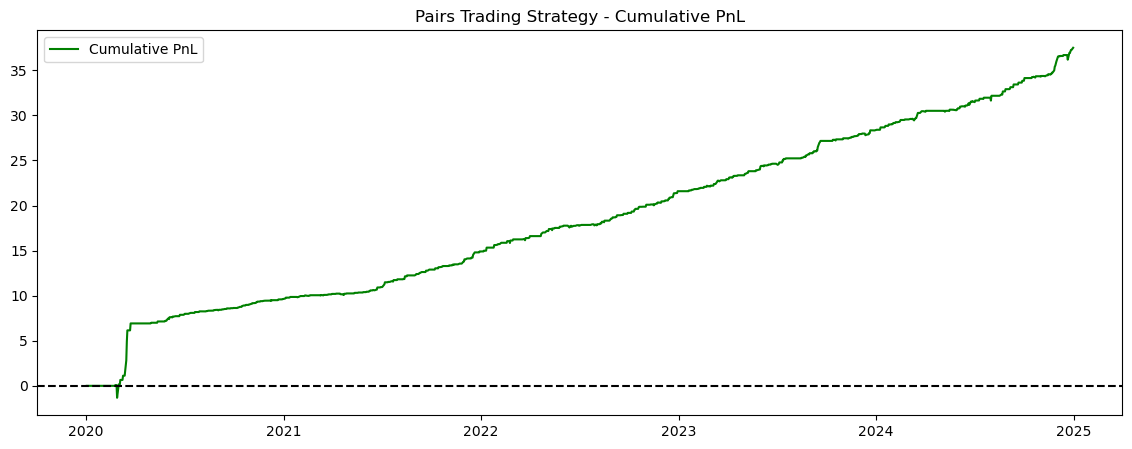

Sharpe Ratio: 3.68
Total PnL: 37.5001


In [12]:
# Backtest - PnL Calculate karo
signals['spread'] = spread
signals['spread_returns'] = signals['spread'].diff()

# Long jab zscore < -1, Short jab zscore > 1
signals['position'] = 0
signals.loc[signals['zscore'] < -1, 'position'] = 1
signals.loc[signals['zscore'] > 1, 'position'] = -1
signals['position'] = signals['position'].shift(1)  # next day execute

signals['strategy_returns'] = signals['position'] * signals['spread_returns']
signals['cumulative_pnl'] = signals['strategy_returns'].cumsum()

# Sharpe Ratio
sharpe = (signals['strategy_returns'].mean() / signals['strategy_returns'].std()) * np.sqrt(252)

# Plot PnL
plt.figure(figsize=(14, 5))
plt.plot(signals['cumulative_pnl'], color='green', label='Cumulative PnL')
plt.axhline(0, color='black', linestyle='--')
plt.title('Pairs Trading Strategy - Cumulative PnL')
plt.legend()
plt.savefig('pairs_trading_pnl.png', dpi=150)
plt.show()

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Total PnL: {signals['cumulative_pnl'].iloc[-1]:.4f}")